# Tutorial 7.1 - Deep Neural Networks (Classification)

### Data description


## Titanic - Machine Learning from Disaster

The sinking of the Titanic is one of the most infamous shipwrecks in history.

On April 15, 1912, during her maiden voyage, the widely considered “unsinkable” RMS Titanic sank after colliding with an iceberg. Unfortunately, there weren’t enough lifeboats for everyone onboard, resulting in the death of 1502 out of 2224 passengers and crew.

While there was some element of luck involved in surviving, it seems some groups of people were more likely to survive than others.

In this challenge, we ask you to build a predictive model that answers the question: “what sorts of people were more likely to survive?” using passenger data (ie name, age, gender, socio-economic class, etc).

### Dataset description

| Variable | Definition                                 | Key                                            |
|----------|--------------------------------------------|------------------------------------------------|
| survival | Survival                                   | 0 = No, 1 = Yes                                |
| pclass   | Ticket class                               | 1 = 1st, 2 = 2nd, 3 = 3rd                      |
| sex      | Sex                                        |                                                |
| Age      | Age in years                               |                                                |
| sibsp    | # of siblings / spouses aboard the Titanic |                                                |
| parch    | # of parents / children aboard the Titanic |                                                |
| ticket   | Ticket number                              |                                                |
| fare     | Passenger fare                             |                                                |
| cabin    | Cabin number                               |                                                |
| embarked | Port of Embarkation                        | C = Cherbourg, Q = Queenstown, S = Southampton |

### Variable notes

pclass: A proxy for socio-economic status (SES).
* 1st = Upper  
* 2nd = Middle  
* 3rd = Lower  

age: Age is fractional if less than 1. If the age is estimated, is it in the form of xx.5  

sibsp: The dataset defines family relations in this way...  
* Sibling = brother, sister, stepbrother, stepsister  
* Spouse = husband, wife (mistresses and fiancés were ignored)  

parch: The dataset defines family relations in this way...  
* Parent = mother, father  
* Child = daughter, son, stepdaughter, stepson  

Some children travelled only with a nanny, therefore parch=0 for them.  on their overall shopping experience (On a scale of 1 to 10)


In [5]:
import pandas as pd
import numpy as np

### Import data

In [6]:
mydata = pd.read_csv('data/titanic.csv')
mydata

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,0,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,0,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,0,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


### Describe the data (numerical columns only)

In [7]:
mydata.info()

<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    str    
 4   Sex          418 non-null    str    
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    str    
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     str    
 11  Embarked     418 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 39.3 KB


Describe the data for numerical columns:

In [8]:
mydata.describe().style.background_gradient(cmap='Oranges')

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


Describe the data for string-related columns:

In [9]:
mydata.describe(include='O')

C:\Users\yhuas\AppData\Local\Temp\ipykernel_37044\1758626570.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  mydata.describe(include='O')


,Name,Sex,Ticket,Cabin,Embarked
count,418,418,418,91,418
unique,418,2,363,76,3
top,"Kelly, Mr. James",male,PC 17608,B57 B59 B63 B66,S
freq,1,266,5,3,270


### Check if any missing values

In [10]:
mydata.isna().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare            True
Cabin           True
Embarked       False
dtype: bool

In [11]:
mydata.isnull().any()

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age             True
SibSp          False
Parch          False
Ticket         False
Fare            True
Cabin           True
Embarked       False
dtype: bool

### Treating missing values (quick and dirty)

In [12]:
mydata['Age'].isna().value_counts()

Age
False    332
True      86
Name: count, dtype: int64

In [13]:
86/(332+86)*100

20.574162679425836

In [14]:
mydata['Age'] = mydata['Age'].fillna(mydata['Age'].mean())

In [15]:
mydata['Fare'].isna().value_counts()

Fare
False    417
True       1
Name: count, dtype: int64

In [16]:
1/418*100

0.23923444976076555

In [17]:
mydata['Fare'] = mydata['Fare'].fillna(mydata['Fare'].mean())

In [18]:
mydata['Cabin'].isna().value_counts()

Cabin
True     327
False     91
Name: count, dtype: int64

In [19]:
91/(91+327)*100

21.770334928229666

In [20]:
mydata['Cabin'].value_counts()

Cabin
B57 B59 B63 B66    3
B45                2
C78                2
C31                2
C23 C25 C27        2
                  ..
B41                1
C7                 1
D40                1
D38                1
C105               1
Name: count, Length: 76, dtype: int64

In [21]:
mydata['Cabin'].mode()

0    B57 B59 B63 B66
Name: Cabin, dtype: str

In [22]:
mydata['Cabin'] = mydata['Cabin'].fillna(mydata['Cabin'].mode()[0])

### Lets do some basic graphing

<Axes: ylabel='Survived'>

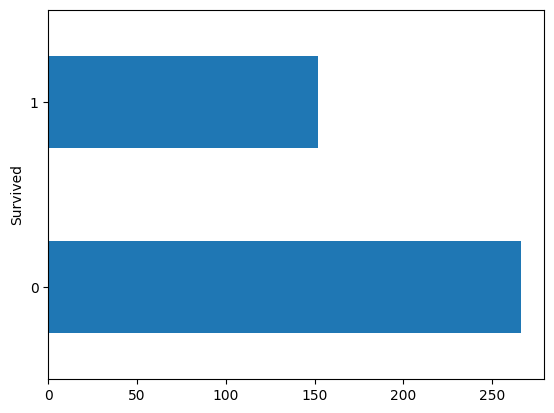

In [23]:
mydata['Survived'].value_counts().plot.barh()

In [24]:
col_list = mydata['Sex'].copy()

In [25]:
col_list[col_list=='male'] = 'Blue'
col_list[col_list=='female'] = 'Red'

<Axes: xlabel='Age', ylabel='Fare'>

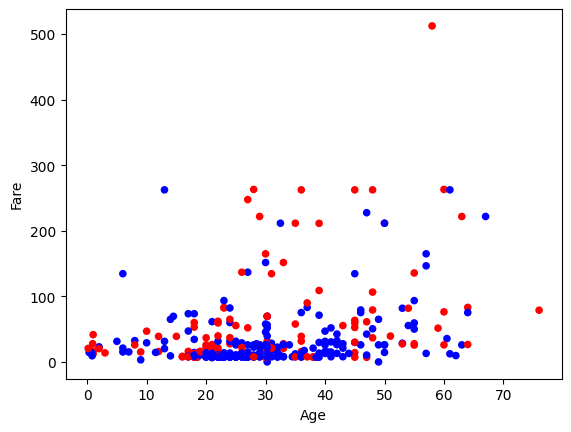

In [26]:
mydata.plot.scatter(x='Age',y='Fare',c=col_list)

## Data Preparation

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

Drop unwanted columns:

In [29]:
mydata = mydata.drop(['PassengerId','Name','Ticket'],axis=1)

Transfrom "string" columns into numerical using an encoder

## Set the objective or target column for prediction

In [30]:
LE=LabelEncoder()

categories=['Sex', 'Cabin', 'Embarked']
for label in categories:
    mydata[label]=LE.fit_transform(mydata[label])

In [31]:
mydata.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,0,3,1,34.5,0,0,7.8292,15,1
1,1,3,0,47.0,1,0,7.0000,15,2
2,0,2,1,62.0,0,0,9.6875,15,1
3,0,3,1,27.0,0,0,8.6625,15,2
4,1,3,0,22.0,1,1,12.2875,15,2


Set the objective or target column for prediction

In [32]:
x = mydata.drop('Survived', axis=1)

In [33]:
x.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,3,1,34.5,0,0,7.8292,15,1
1,3,0,47.0,1,0,7.0000,15,2
2,2,1,62.0,0,0,9.6875,15,1
3,3,1,27.0,0,0,8.6625,15,2
4,3,0,22.0,1,1,12.2875,15,2


In [34]:
y = mydata['Survived']

In [35]:
y.head()

0    0
1    1
2    0
3    0
4    1
Name: Survived, dtype: int64

In [36]:
x_train, x_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)

In [37]:
x_valid, x_test, y_valid, y_test = train_test_split(x_temp, y_temp, test_size=0.5, random_state=42)

## Deep Learning Model

We are going to use Keras, a deep learning framework (simplified).
Keras is now embedded in Google Tensorflow.

Target column: Survived  
Column datatype: Numerical  
Task: Classification  

`!pip install tensorflow`  

In [38]:
import tensorflow as tf

### Define our deep learning model

In [39]:
x_train.shape

(334, 8)

So 8 columns, means 8 neurons for input

In [41]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(8,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(2, activation='softmax')
])

In [42]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 706 (2.76 KB)

 Trainable params: 706 (2.76 KB)

 Non-trainable params: 0 (0.00 B)

### Prepare the optimizers, loss functions and evaluation metrics

In [43]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

### Train the model using the training set (70%)

In [44]:
model.fit(x_train, 
          y_train, 
          epochs=10,
          validation_data = (x_valid,y_valid))

Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.6467 - loss: 2.7870 - val_accuracy: 0.5238 - val_loss: 0.9559
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.4012 - loss: 0.9680 - val_accuracy: 0.5238 - val_loss: 0.6304
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6527 - loss: 0.7171 - val_accuracy: 0.6667 - val_loss: 0.7143
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6527 - loss: 0.7031 - val_accuracy: 0.6667 - val_loss: 0.5682
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6407 - loss: 0.6449 - val_accuracy: 0.6667 - val_loss: 0.5969
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6407 - loss: 0.6229 - val_accuracy: 0.6667 - val_loss: 0.5510
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.6467 - loss: 0.6201 - val_accuracy: 0.6667 - val_loss: 0.5322
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6587 - loss: 0.5906 - val_accuracy: 0.6667 - v

In [45]:
model.evaluate(x_train, y_train)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7096 - loss: 0.5206 


[0.5205941796302795, 0.7095808386802673]

### Evaluate the model on the validation set (10%)

In [46]:
model.evaluate(x_valid, y_valid)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6905 - loss: 0.5086


[0.5085845589637756, 0.6904761791229248]

### Evaluate the model on the testing set (10%)

In [47]:
model.evaluate(x_test, y_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6429 - loss: 0.6058


[0.6057513356208801, 0.6428571343421936]

## Well, What If We Use Traditional Machine Learning 

In [48]:
from sklearn.ensemble import RandomForestClassifier

In [49]:
randf = RandomForestClassifier()

In [50]:
randf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [51]:
randf.score(x_train, y_train)*100

100.0

In [52]:
randf.score(x_valid, y_valid)*100

100.0

In [53]:
randf.score(x_test, y_test)*100

100.0